In [1]:
import sys, pathlib
root = pathlib.Path.cwd()
if not (root / "src").is_dir():          # walk up until we find src/
    root = next(p for p in root.parents if (p / "src").is_dir())
sys.path.insert(0, str(root / "src"))    # src-layout: package lives under src/ (or `pip install -e .`)

from stage_discharge.read_write import read_hobo_log, read_vusitu_log, clean_hobo_log, clean_vusitu_log
from stage_discharge.build_stage import calc_diff_pressure, calc_depth, build_stage
from stage_discharge.hobo_fetch import fetch_licor_data, tidy_licor_data
from stage_discharge.rating_curve import RatingCurve
from stage_discharge.conversions import to_units
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
tests = root / "imports" / "tests"    # bundled sample logs, path-independent

# clean_* take just the frame now and return a DataFrame (UTC index + SI units);
# read_* still hand back a units dict, but nothing downstream needs it.
header_abs, data_abs, _ = read_vusitu_log(
    tests / "VuSitu_Log_2025-10-15_18-00-00_dolan_xing_tube_20251015_dolanXing.csv",
    pressure_kind='absolute')
data_abs = clean_vusitu_log(data_abs)

header_baro, data_baro, _ = read_vusitu_log(
    tests / "VuSitu_Log_2025-10-15_18-00-00_Dolan_Baro_20251015_DolanBaro.csv",
    pressure_kind='barometric')
data_baro = clean_vusitu_log(data_baro)

data, _ = read_hobo_log(tests / "DEV300_20260914_export3-2026_09_14_14_16_02_UTC.csv")
data = clean_hobo_log(data)

c:\Users\will\OneDrive\Documents\Python programming\stage_discharge\stage_discharge\src\stage_discharge\read_write.py:210: UserWarning: HOBO: unrecognized measurement 'line' -- passing it through un-aliased. Add it to standard_names if it's real.
  key = _apply_alias(key, sn.HOBO_ALIASES, "HOBO")


In [3]:
data

,diff_pressure_pa,abs_pressure_pa,temperature_c,water_level_m,baro_pressure_pa
datetime,,,,,
2026-04-22 16:15:00+00:00,NaN,NaN,20.944444,0.208818,NaN
2026-04-22 16:20:00+00:00,NaN,NaN,20.944444,0.208818,NaN
2026-04-22 16:25:00+00:00,NaN,NaN,20.944444,0.207935,NaN
2026-04-22 16:30:00+00:00,NaN,NaN,20.944444,0.206715,NaN
2026-04-22 16:35:00+00:00,NaN,NaN,21.000000,0.205222,NaN
...,...,...,...,...,...
2026-09-11 19:15:00+00:00,347.495753,96665.182616,30.611111,0.161178,96317.686863
2026-09-11 19:30:00+00:00,333.706239,96623.814074,30.722222,0.159776,96290.107835
2026-09-11 19:45:00+00:00,335.774666,96599.682424,30.777778,0.159959,96263.907758


In [4]:
vudolan = pd.merge_asof(
    data_abs.sort_index(), data_baro.sort_index(),
    left_index=True, right_index=True,
    direction="nearest",
    tolerance=pd.Timedelta("1s"),      # pair a reading only with a baro sample within 1 s
    suffixes=("_abs", "_baro"),
)

In [5]:
# columns are SI now: abs_pressure_pa / baro_pressure_pa (temperature_c collided -> _abs/_baro)
diff_log = calc_diff_pressure(vudolan['abs_pressure_pa'], vudolan['baro_pressure_pa'])
stage_log = calc_depth(diff_log, vudolan['temperature_c_abs'])

# equivalently, build_stage does both with the SI + UTC guards applied:
# stage = build_stage(vudolan, temp_col='temperature_c_abs')  # adds diff_pressure_pa, water_level_m

In [6]:
dolan_hobo = fetch_licor_data(serial_number=22475388, start_date="2026-07-01 12:00:00", end_date="2026-09-13 12:00:00", token = 'oJ5W88JkMtRTxYnTtMXGSal5v3iOwqD728WvKnulhIsHXjw3', report = True)
dolan_hobo, units = tidy_licor_data(dolan_hobo)

OK: Found: 34820 results., sensors = ['Absolute Pressure', 'Barometric Pressure', 'Diff Pressure', 'Temperature', 'Water Level']


In [7]:
units

{'diff_pressure_psi': 'psi',
 'abs_pressure_psi': 'psi',
 'temperature_f': '°F',
 'water_level_feet': 'feet',
 'baro_pressure_psi': 'psi'}

sensor_measurement_type    abs_pressure_pa  baro_pressure_pa  \
datetime                                                       
2026-07-01 12:00:00+00:00     97312.117852      96722.999158   
2026-07-01 12:15:00+00:00     97289.943701      96708.998115   
2026-07-01 12:30:00+00:00     97294.381100      96720.997197   
2026-07-01 12:45:00+00:00     97294.381100      96726.001066   
2026-07-01 13:00:00+00:00     97316.548676      96746.998186   

sensor_measurement_type    diff_pressure_pa  temperature_c  water_level_m  
datetime                                                                   
2026-07-01 12:00:00+00:00        589.118694      24.283115       0.185792  
2026-07-01 12:15:00+00:00        580.945586      24.283115       0.185016  
2026-07-01 12:30:00+00:00        573.383903      24.283115       0.184240  
2026-07-01 12:45:00+00:00        568.380034      24.283115       0.183676  
2026-07-01 13:00:00+00:00        569.550490      24.283115       0.183817  


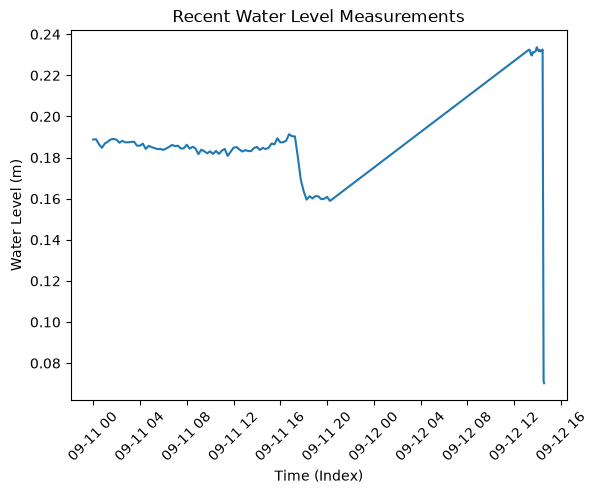

In [8]:
print(dolan_hobo.head())

import matplotlib.pyplot as plt

# Plotting the data
plt.plot(dolan_hobo['water_level_m'][-100:-1])

# Labeling the axes
plt.xlabel('Time (Index)')
plt.ylabel('Water Level (m)')
plt.title('Recent Water Level Measurements')
plt.xticks(rotation=45)

plt.show()
 # SI: water_level_m (was water_level_feet before conversion)

In [9]:
# Field gaugings: staff-gage stage (ft) + discharge (cfs). Name the columns with
# their US unit suffix, then to_units converts the whole frame to SI in one call.
gaugings = pd.read_csv(tests / "dolan_stage_discharge.csv").rename(
    columns={"New Staff Gage": "water_level_ft", "Q_cfs": "discharge_cfs"})
gaugings = to_units(gaugings, "SI")     # -> water_level_m, discharge_cms
gaugings.head()

,water_level_m,discharge_cms
0,0.192024,0.890565
1,0.198120,1.076040
2,0.204216,1.238296
3,0.204216,1.274824
4,0.225552,1.520331


findfont: Failed to find font weight semibold, now using 700.


fitted params: [103.99736787  -0.14379354   4.23457864]


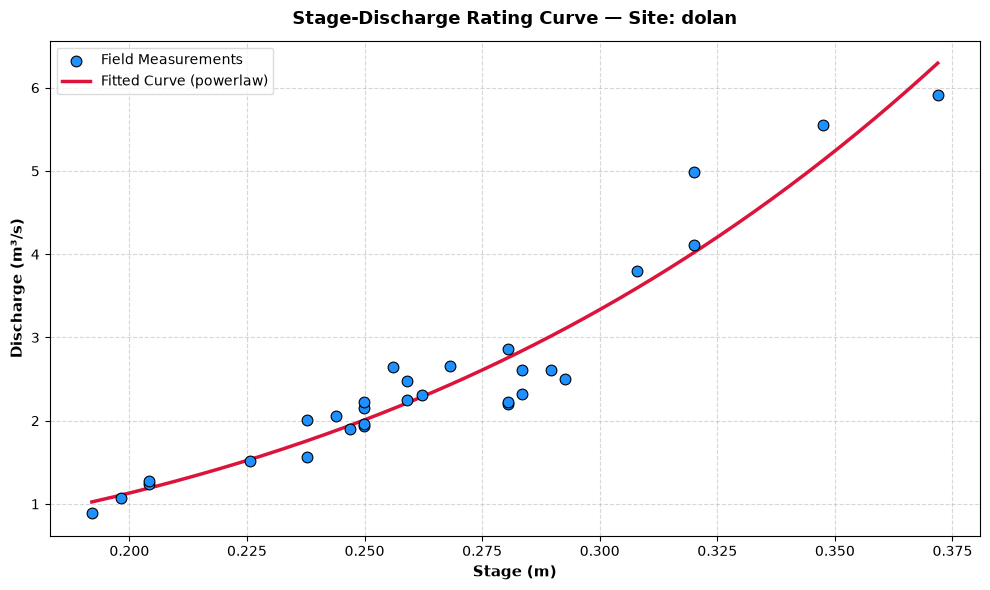

In [10]:
# Fit the rating on the SI gaugings. stage is named water_level_m, so RatingCurve's
# SI guard is satisfied; powerlaw now seeds p0 internally so it converges.
rc = RatingCurve("dolan")
rc.stage, rc.discharge = gaugings["water_level_m"], gaugings["discharge_cms"]
rc.calculate_curve("powerlaw")   # use "log_linear" if a fit ever fails to converge
print("fitted params:", rc.popt)
rc.plot_measurements()

In [ ]:
#type(hobo_discharge)

NameError: name 'hobo_discharge' is not defined

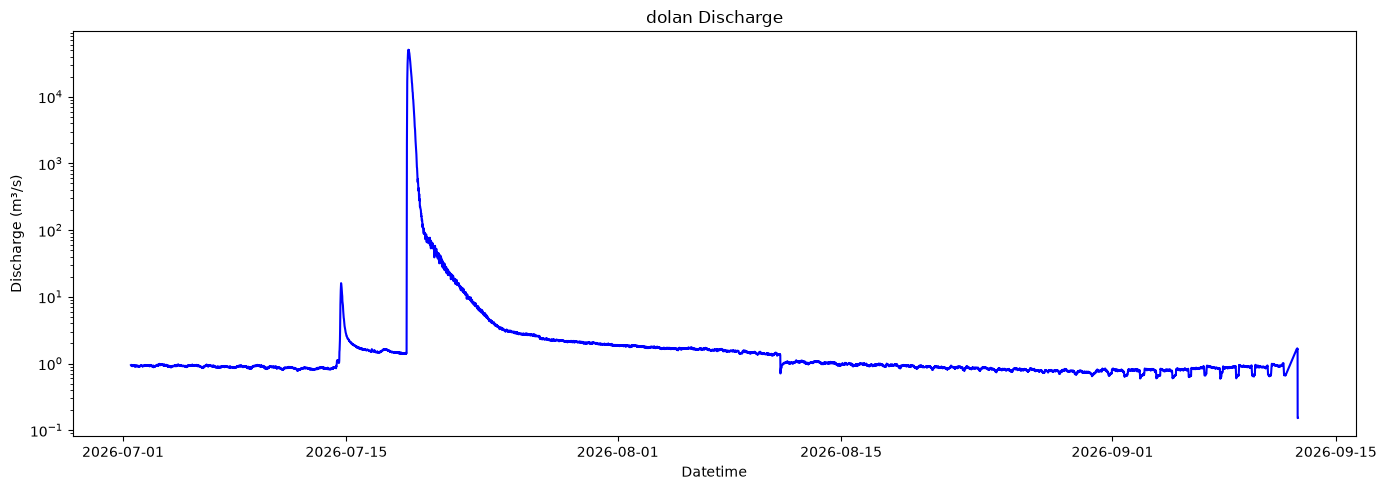

In [ ]:
hobo_discharge = pd.Series(rc.predict(dolan_hobo['water_level_m']), index = dolan_hobo.index, name = 'discharge_m3s')
rc.plot_discharge(dolan_hobo['water_level_m'], yscale = 'log')

In [ ]:
hobo_discharge

datetime
2026-07-01 12:00:00+00:00    0.945844
2026-07-01 12:15:00+00:00    0.936453
2026-07-01 12:30:00+00:00    0.927132
2026-07-01 12:45:00+00:00    0.920399
2026-07-01 13:00:00+00:00    0.922079
                               ...   
2026-09-12 14:20:38+00:00    1.644810
2026-09-12 14:25:38+00:00    1.659309
2026-09-12 14:30:43+00:00    0.154921
2026-09-12 14:33:09+00:00    0.151991
2026-09-12 14:48:09+00:00    0.152382
Name: discharge, Length: 6964, dtype: float64

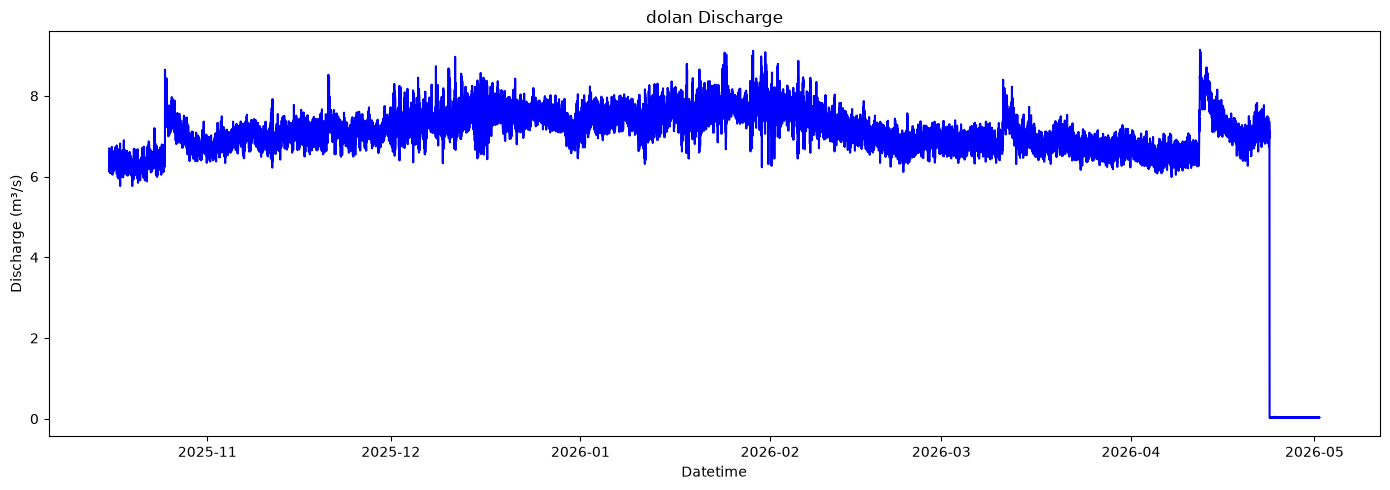

In [13]:
# Apply the rating to the VuSitu stage. build_stage output is SI + UTC, so the
# water_level_m series passes RatingCurve's SI + UTC guards.
stage = build_stage(vudolan, temp_col="temperature_c_abs")
discharge = pd.Series(rc.predict(stage["water_level_m"]), index=stage.index, name="discharge_cms")
rc.plot_discharge(stage['water_level_m'])

In [ ]:
# The one place units re-enter: convert results back to US for reporting/export.
# to_units reads each column's SI suffix and rewrites value + suffix in lockstep.
stage_us = to_units(stage[["water_level_m"]], "US")   # -> water_level_ft
stage_us.head()

,water_level_ft
datetime,
2025-10-15 23:00:00.056000+00:00,1.244893
2025-10-15 23:15:00.056000+00:00,1.218182
2025-10-15 23:30:00.056000+00:00,1.212870
2025-10-15 23:45:00.056000+00:00,1.226205
2025-10-16 00:00:00.056000+00:00,1.216104
